
# Yixuan Chen - CMPINF 0010 Final Project Notebook
## City of Pittsburgh Trees: Which neighborhood has the strongest urban forest?

### Introduction

For my part of the final project, I used the **City of Pittsburgh Trees** dataset to study one possible version of "best neighborhood": the neighborhood with the strongest city-maintained urban forest. I chose this dataset because trees are tied to several things that make a neighborhood more livable, including stormwater control, air quality, carbon benefits, and overall environmental value.

This notebook focuses on a single sub-metric that my group could combine with other members' metrics later. My question is:

> **If we judge neighborhoods by the quantity and environmental value of their city-maintained trees, which Pittsburgh neighborhood looks best?**

Instead of using just one number, I build a small **Green Benefit Score** that rewards:
1. neighborhoods with many city-maintained trees,
2. neighborhoods with high total estimated environmental benefit, and
3. neighborhoods whose trees have strong average benefit per tree.

This keeps the analysis from being too simplistic. If I only looked at tree count, I would ignore tree quality. If I only looked at average benefit, very small neighborhoods could look artificially strong.



## The dataset

This notebook uses the WPRDC **City of Pittsburgh Trees** dataset. Each row represents a city-maintained tree and includes:
- the neighborhood
- tree characteristics such as height and diameter
- condition information
- estimated benefit fields such as stormwater, air quality, carbon, property, and overall benefits

For this project, the most important columns are:
- `neighborhood`
- `overall_benefits_dollar_value`
- `stormwater_benefits_dollar_value`
- `air_quality_benfits_total_dollar_value`
- `co2_benefits_dollar_value`
- `property_value_benefits_dollarvalue`

I also use tree count as part of the neighborhood score.


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import glob

# Try to find the dataset in the current folder
possible_paths = [
    Path("city_trees.csv"),
    Path("City_of_Pittsburgh_Trees.csv"),
]

csv_path = None
for path in possible_paths:
    if path.exists():
        csv_path = path
        break

if csv_path is None:
    csv_files = glob.glob("*.csv")
    if csv_files:
        csv_path = Path(csv_files[0])
    else:
        raise FileNotFoundError("No CSV dataset was found in the notebook folder.")

trees = pd.read_csv(csv_path, low_memory=False)
trees.head()


,_id,id,address_number,street,common_name,scientific_name,height,width,growth_space_length,growth_space_width,...,neighborhood,council_district,ward,tract,public_works_division,pli_division,police_zone,fire_zone,latitude,longitude
0,1,754166088,7428,MONTICELLO ST,Stump,Stump,0.0,0.0,10.0,2.0,...,Homewood North,9.0,13.0,4.200313e+10,2.0,13.0,5.0,3-17,40.458169,-79.889724
1,2,1946899269,220,BALVER AVE,Linden: Littleleaf,Tilia cordata,0.0,0.0,99.0,99.0,...,Oakwood,2.0,28.0,4.200356e+10,5.0,28.0,6.0,1-19,40.429269,-80.067868
2,3,1431517397,2822,SIDNEY ST,Maple: Red,Acer rubrum,22.0,6.0,6.0,3.0,...,South Side Flats,3.0,16.0,4.200316e+10,3.0,16.0,3.0,4-24,40.426797,-79.965035
3,4,994063598,608,SUISMON ST,Maple: Freeman,Acer x freemanii,25.0,10.0,3.0,3.0,...,East Allegheny,1.0,23.0,4.200356e+10,1.0,23.0,1.0,1-6,40.455503,-79.999276
4,5,1591838573,1135,N NEGLEY AVE,Maple: Norway,Acer platanoides,52.0,13.0,99.0,99.0,...,Highland Park,7.0,11.0,4.200311e+10,2.0,11.0,5.0,3-9,40.476667,-79.924106


In [3]:

print(f"Dataset file: {csv_path}")
print(f"Rows: {trees.shape[0]}")
print(f"Columns: {trees.shape[1]}")
print(f"Neighborhoods listed: {trees['neighborhood'].nunique(dropna=True)}")

trees[['neighborhood', 'common_name', 'overall_benefits_dollar_value']].head(10)


Dataset file: 1515a93c-73e3-4425-9b35-1cd11b2196da.csv
Rows: 45709
Columns: 59
Neighborhoods listed: 90


,neighborhood,common_name,overall_benefits_dollar_value
0,Homewood North,Stump,NaN
1,Oakwood,Linden: Littleleaf,125.178322
2,South Side Flats,Maple: Red,77.767116
3,East Allegheny,Maple: Freeman,81.838259
4,Highland Park,Maple: Norway,390.538994
5,Highland Park,Oak: Pin,206.575018
6,Highland Park,Dogwood: Corneliancherry,15.347590
7,Highland Park,Maple: Norway,115.787785
8,Highland Park,Maple: Norway,167.445388
9,Stanton Heights,Maple: Norway,NaN



## Cleaning and preparing the data

To make the analysis more stable:
- I drop rows with missing neighborhood names.
- I convert the benefit columns to numeric values.
- I group the data by neighborhood.
- I exclude neighborhoods with fewer than **100 city-maintained trees** so that tiny sample sizes do not dominate the ranking.

That last decision is important. A very small neighborhood can sometimes have a high average value by chance, but I want the score to represent a meaningful neighborhood-level pattern.


In [4]:

benefit_cols = [
    'overall_benefits_dollar_value',
    'stormwater_benefits_dollar_value',
    'air_quality_benfits_total_dollar_value',
    'co2_benefits_dollar_value',
    'property_value_benefits_dollarvalue'
]

for col in benefit_cols + ['height', 'width', 'diameter_base_height']:
    trees[col] = pd.to_numeric(trees[col], errors='coerce')

clean = trees.dropna(subset=['neighborhood']).copy()

neighborhood_stats = clean.groupby('neighborhood').agg(
    tree_count=('id', 'count'),
    total_benefit=('overall_benefits_dollar_value', 'sum'),
    avg_benefit=('overall_benefits_dollar_value', 'mean'),
    total_stormwater=('stormwater_benefits_dollar_value', 'sum'),
    total_air=('air_quality_benfits_total_dollar_value', 'sum'),
    total_co2=('co2_benefits_dollar_value', 'sum'),
    total_property=('property_value_benefits_dollarvalue', 'sum'),
    median_dbh=('diameter_base_height', 'median')
)

# Keep neighborhoods with enough trees to make the comparison fairer
neighborhood_stats = neighborhood_stats[neighborhood_stats['tree_count'] >= 100].copy()

neighborhood_stats.sort_values('tree_count', ascending=False).head(10)


,tree_count,total_benefit,avg_benefit,total_stormwater,total_air,total_co2,total_property,median_dbh
neighborhood,,,,,,,,
Squirrel Hill South,5073,699252.085243,142.967100,65420.140135,46379.727424,5883.151399,286319.342311,15.0
Highland Park,2941,407317.417576,148.982230,38990.752395,27781.014184,3651.800363,162721.293487,16.0
Squirrel Hill North,2083,315094.287540,168.499619,33369.308386,23199.064989,2985.539720,118348.742524,18.5
South Side Flats,1693,115952.678237,77.664219,6053.708437,5204.347628,696.743625,67263.969296,6.0
Shadyside,1558,166934.913440,126.946702,13357.984301,9858.798260,1289.363477,75042.753217,11.0
Bloomfield,1436,113356.294885,96.146136,7527.527154,5976.191339,791.018862,57972.658677,6.0
East Liberty,1366,102570.406756,82.784832,6343.921387,5059.976119,626.164719,53386.019590,5.0
Point Breeze,1316,170153.645336,147.064516,16810.143935,12034.065545,1570.195297,66381.196066,15.0
Perry North,1007,136752.635834,147.681032,12059.409396,8574.533146,1083.745922,56286.033724,15.0



## The metric

I define a **Green Benefit Score** using normalized values from three parts:

- **50% total overall benefit**  
  This is the most important part because it captures the neighborhood's total environmental value from its city trees.

- **30% tree count**  
  A neighborhood with more trees usually has a stronger city-maintained green presence.

- **20% average benefit per tree**  
  This rewards neighborhoods whose trees are individually more valuable on average.

Formula:

\[
\text{{Green Benefit Score}} = 0.5(\text{{Total Benefit Norm}}) + 0.3(\text{{Tree Count Norm}}) + 0.2(\text{{Average Benefit Norm}})
\]

I am not claiming this is the only valid metric. It is just a reasonable, transparent one for an environmental-quality argument.


In [5]:

for col in ['tree_count', 'total_benefit', 'avg_benefit']:
    neighborhood_stats[col + '_norm'] = (
        (neighborhood_stats[col] - neighborhood_stats[col].min()) /
        (neighborhood_stats[col].max() - neighborhood_stats[col].min())
    )

neighborhood_stats['green_score'] = (
    0.5 * neighborhood_stats['total_benefit_norm'] +
    0.3 * neighborhood_stats['tree_count_norm'] +
    0.2 * neighborhood_stats['avg_benefit_norm']
)

ranking = neighborhood_stats.sort_values('green_score', ascending=False).copy()
ranking[['tree_count', 'total_benefit', 'avg_benefit', 'green_score']].head(10).round(2)


,tree_count,total_benefit,avg_benefit,green_score
neighborhood,,,,
Squirrel Hill South,5073,699252.09,142.97,0.96
Highland Park,2941,407317.42,148.98,0.63
Squirrel Hill North,2083,315094.29,168.50,0.54
Point Breeze,1316,170153.65,147.06,0.35
Allegheny Center,867,147912.81,171.79,0.35
Shadyside,1558,166934.91,126.95,0.33
Perry North,1007,136752.64,147.68,0.31
Stanton Heights,700,104939.39,168.71,0.30
Lincoln-Lemington-Belmar,525,72837.00,153.34,0.25



## Visualization 1: Top neighborhoods by Green Benefit Score

This chart shows the top ten neighborhoods under my metric.


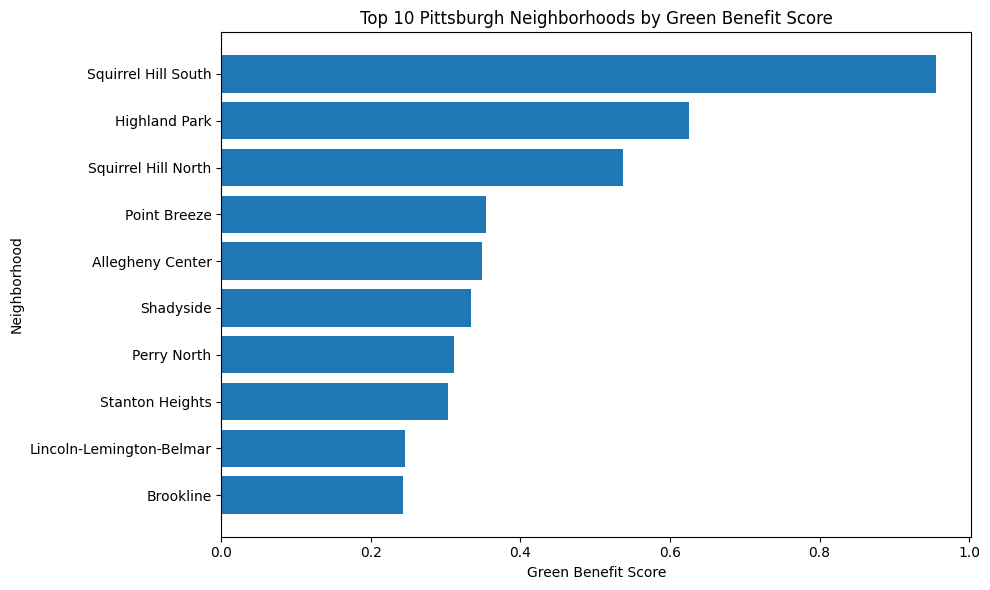

In [6]:

top10 = ranking.head(10).sort_values('green_score')

plt.figure(figsize=(10, 6))
plt.barh(top10.index, top10['green_score'])
plt.xlabel("Green Benefit Score")
plt.ylabel("Neighborhood")
plt.title("Top 10 Pittsburgh Neighborhoods by Green Benefit Score")
plt.tight_layout()
plt.show()



The leading neighborhood is clearly separated from the rest. That matters because it means the result is not just a tiny edge caused by rounding.



## Visualization 2: Tree count vs. total overall benefit

This plot helps explain *why* certain neighborhoods rank well. In general, neighborhoods with more city-maintained trees also have greater total estimated benefit, but some neighborhoods still perform better than others for the same rough scale.


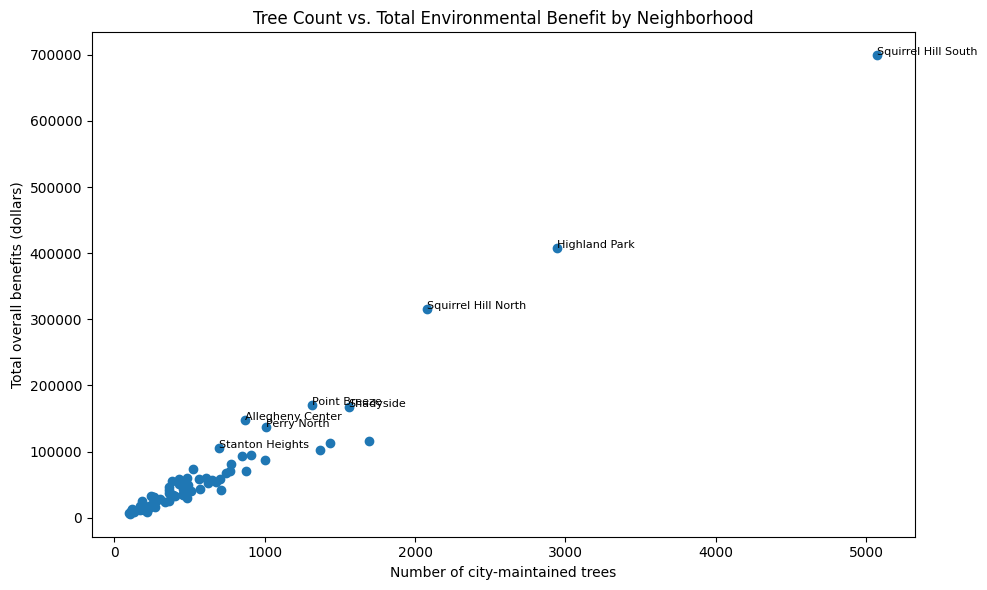

In [7]:

top_labels = set(ranking.head(8).index)

plt.figure(figsize=(10, 6))
plt.scatter(ranking['tree_count'], ranking['total_benefit'])

for name, row in ranking.iterrows():
    if name in top_labels:
        plt.annotate(name, (row['tree_count'], row['total_benefit']), fontsize=8)

plt.xlabel("Number of city-maintained trees")
plt.ylabel("Total overall benefits (dollars)")
plt.title("Tree Count vs. Total Environmental Benefit by Neighborhood")
plt.tight_layout()
plt.show()



## Visualization 3: Benefit breakdown for the top 5 neighborhoods

The dataset also breaks overall value into different types of benefit. This chart compares the top five neighborhoods using stormwater, air quality, carbon, and property-related benefits.


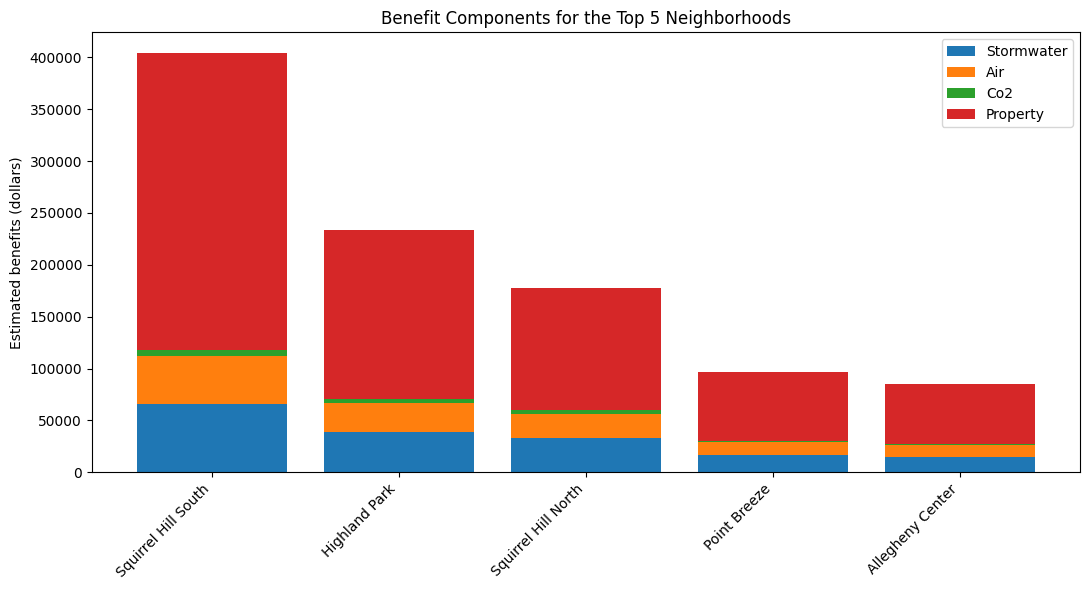

In [8]:

top5 = ranking.head(5)[['total_stormwater', 'total_air', 'total_co2', 'total_property']]

plt.figure(figsize=(11, 6))
bottom = np.zeros(len(top5))

for col in top5.columns:
    plt.bar(top5.index, top5[col], bottom=bottom, label=col.replace('total_', '').replace('_', ' ').title())
    bottom += top5[col].fillna(0).to_numpy()

plt.xticks(rotation=45, ha='right')
plt.ylabel("Estimated benefits (dollars)")
plt.title("Benefit Components for the Top 5 Neighborhoods")
plt.legend()
plt.tight_layout()
plt.show()



## The best neighborhood according to this notebook

According to my Green Benefit Score, **Squirrel Hill South** is the best neighborhood in Pittsburgh for this sub-metric.

Why Squirrel Hill South wins:
- It has **5,073** city-maintained trees in the dataset.
- Its total overall tree benefit is about **$699,252.09**, the highest among neighborhoods that met the sample threshold.
- Its average benefit per tree is about **$142.97**.

For comparison:
- **Highland Park** ranks second with a score of **0.625**.
- **Squirrel Hill North** ranks third with a score of **0.537**.
- **Squirrel Hill South** still remains well ahead, with a score of **0.955**.

This makes Squirrel Hill South a strong choice if "best" means a neighborhood with a large and high-value urban forest that provides visible environmental benefits.


In [8]:

ranking[['tree_count', 'total_benefit', 'avg_benefit', 'green_score']].head(15).round(2)


,tree_count,total_benefit,avg_benefit,green_score
neighborhood,,,,
Squirrel Hill South,5073,699252.09,142.97,0.96
Highland Park,2941,407317.42,148.98,0.63
Squirrel Hill North,2083,315094.29,168.50,0.54
Point Breeze,1316,170153.65,147.06,0.35
Allegheny Center,867,147912.81,171.79,0.35
Shadyside,1558,166934.91,126.95,0.33
Perry North,1007,136752.64,147.68,0.31
Stanton Heights,700,104939.39,168.71,0.30
Lincoln-Lemington-Belmar,525,72837.00,153.34,0.25



## Conclusion

My personal takeaway is that the answer depends on what "best" is supposed to mean. This notebook does **not** prove that one neighborhood is universally the best place to live. Instead, it shows that if we care about city-managed green infrastructure and environmental tree benefits, some neighborhoods stand out very clearly.

Using this dataset, **Squirrel Hill South** comes out on top because it combines scale and value. It has a very large number of trees, and those trees contribute a very high total level of estimated benefit. In that sense, it looks like the strongest neighborhood in Pittsburgh for urban forest impact.

At the same time, this result also shows the limits of data-driven rankings. A neighborhood could be someone's favorite because of food, walkability, safety, housing, or personal memories, and none of that is captured here. So I would describe this notebook as one strong piece of the final group argument, not the whole story. For the group project, this metric would work best when combined with other datasets that measure different aspects of neighborhood life.
